## 1. Install and imports

In [ ]:
import importlib.util, subprocess, sys

if importlib.util.find_spec("diffusers") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "diffusers"])
if importlib.util.find_spec("torch") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch",
                           "--index-url", "https://download.pytorch.org/whl/cpu"])

import json
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from diffusers import DDPMScheduler
from torch.utils.data import BatchSampler, DataLoader, Dataset, RandomSampler, SequentialSampler
from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)


PyTorch: 2.11.0+cu128


## 2. Settings

Upload the zip file with pca data into your /content folder then run the next cell

In [ ]:
!unzip 25lines_100drugs_pca_data.zip

Archive:  25lines_100drugs_pca_data.zip
   creating: content/data/
   creating: content/data/Tahoe/
   creating: content/data/Tahoe/subsets/
   creating: content/data/Tahoe/subsets/cfg_25lines_100drugs/
   creating: content/data/Tahoe/subsets/cfg_25lines_100drugs/metadata/
  inflating: content/data/Tahoe/subsets/cfg_25lines_100drugs/plan.json  
  inflating: content/data/Tahoe/subsets/cfg_25lines_100drugs/download_status.json  
  inflating: content/data/Tahoe/subsets/cfg_25lines_100drugs/download_progress.json  
  inflating: content/data/Tahoe/subsets/cfg_25lines_100drugs/coverage_report.json  
   creating: content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/
   creating: content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/
  inflating: content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/manifest.json  
   creating: content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/pca50_hvg2000/
  inflating: content/data

In [ ]:
PCA_DIR = Path("/content/content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/pca50_hvg2000")  # point this at your downloaded PCA_DIR folder
OUT_DIR = Path("/content/checkpoint/diffusion_cfg_checkpoints")

BATCH_SIZE = 256
SEED = 42
NUM_TRAIN_TIMESTEPS = 1000
CFG_DROPOUT_PROB = 0.1     # probability of training on the null (unconditional) id pair, as in cifar_diffusion.py
EPOCHS = 50
LR = 2e-4

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Device:", DEVICE, "| PCA_DIR:", PCA_DIR)


Device: cuda | PCA_DIR: /content/content/data/Tahoe/subsets/cfg_25lines_100drugs/splits/pair_seed42_val20_raw4/pca50_hvg2000


## 3. The self-contained PCA loader

Unchanged from the main notebook's section 7e -- pasted verbatim so this notebook has no dependency on it.

In [ ]:
def make_hvg_col(hvg_ids):
    hvg_col = np.full(int(hvg_ids.max()) + 1, -1, dtype=np.int64)
    hvg_col[hvg_ids] = np.arange(len(hvg_ids))
    return hvg_col


def load_pca_model(pca_dir=PCA_DIR):
    with np.load(pca_dir / "pca_model.npz") as saved:
        model = {key: saved[key] for key in saved.files}
    model["pc_scale"] = float(model["pc_scale"])
    model["hvg_col"] = make_hvg_col(model["hvg_ids"])
    return model


class TahoePCs(Dataset):

    def __init__(self, split, pca_dir=PCA_DIR, pc_scale=None):
        pca_dir = Path(pca_dir)
        labels = json.loads((pca_dir / "pca_manifest.json").read_text())
        pcs = np.load(pca_dir / f"pcs_{split}.npy")
        keep = np.isfinite(pcs).all(axis=1)      # all rows unless this was a MAX_BATCHES smoke run
        self.pc_scale = float(np.load(pca_dir / "pca_model.npz")["pc_scale"]) if pc_scale is None else pc_scale
        self.pcs = torch.from_numpy(pcs[keep] / self.pc_scale).float()
        self.cluster = torch.from_numpy(np.load(pca_dir / f"cluster_{split}.npy")[keep].astype(np.int64))
        self.drug_id = np.load(pca_dir / f"drug_id_{split}.npy")[keep].astype(np.int64)
        self.line_id = np.load(pca_dir / f"line_id_{split}.npy")[keep].astype(np.int64)
        self.drug_names = np.asarray(labels["drug_names"])
        self.line_names = np.asarray(labels["line_names"])
        self.is_control = torch.from_numpy(self.drug_id == 0)

    def __len__(self):
        return len(self.pcs)

    def __getitem__(self, index):
        index = np.asarray(index)
        return {"pcs": self.pcs[index], "drug": self.drug_names[self.drug_id[index]].tolist(),
                "cell_line_id": self.line_names[self.line_id[index]].tolist(),
                "cluster": self.cluster[index], "is_control": self.is_control[index]}


def make_pca_loaders(batch_size=256, seed=SEED, pca_dir=PCA_DIR):
    train_ds = TahoePCs("train", pca_dir)
    val_ds = TahoePCs("validation", pca_dir, pc_scale=train_ds.pc_scale)
    generator = torch.Generator().manual_seed(seed)
    train = DataLoader(train_ds, batch_size=None, num_workers=0,
                       sampler=BatchSampler(RandomSampler(train_ds, generator=generator), batch_size, drop_last=True))
    validation = DataLoader(val_ds, batch_size=None, num_workers=0,
                            sampler=BatchSampler(SequentialSampler(val_ds), batch_size, drop_last=False))
    return train, validation


def pcs_to_hvg_expression(pcs, model=None):
    model = load_pca_model() if model is None else model
    z = (np.asarray(pcs, dtype=np.float64) * model["pc_scale"]) @ model["components"] + model["pca_mean"]
    return z * model["scaler_std"] + model["scaler_mean"]


## 4. Build the loaders and the drug / cell-line vocabulary

`TahoePCs` batches only carry `drug`/`cell_line_id` as strings (matching the raw four-field loader's convention), so the model's embeddings need a small string -> id lookup. `drug_names`/`line_names` already give exactly that mapping (a name's position in the list is its integer id). One extra id per vocabulary (`NULL_DRUG_ID`, `NULL_LINE_ID`) is reserved for the unconditional/CFG-dropout case.

In [ ]:
train_loader, validation_loader = make_pca_loaders(batch_size=BATCH_SIZE, seed=SEED, pca_dir=PCA_DIR)
print("Training cells:", len(train_loader.dataset), "| Validation cells:", len(validation_loader.dataset))

DATA_DIM = train_loader.dataset.pcs.shape[1]
drug_names = train_loader.dataset.drug_names.tolist()
line_names = train_loader.dataset.line_names.tolist()
drug_to_id = {name: i for i, name in enumerate(drug_names)}
line_to_id = {name: i for i, name in enumerate(line_names)}
NULL_DRUG_ID, NULL_LINE_ID = len(drug_names), len(line_names)

batch = next(iter(train_loader))
print("pcs:", tuple(batch["pcs"].shape), "| e.g. drug:", batch["drug"][0], "| e.g. cell line:", batch["cell_line_id"][0])
print(f"{len(drug_names)} drugs (null id {NULL_DRUG_ID}), {len(line_names)} cell lines (null id {NULL_LINE_ID}), "
      f"data dim {DATA_DIM}")


Training cells: 791249 | Validation cells: 200650
pcs: (256, 50) | e.g. drug: DMSO_TF | e.g. cell line: CVCL_C466
101 drugs (null id 101), 25 cell lines (null id 25), data dim 50


## 5. Model

In [ ]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        half = dim // 2
        freqs = torch.exp(-math.log(10000.0) * torch.arange(half) / max(half - 1, 1))
        self.register_buffer("freqs", freqs, persistent=False)

    def forward(self, t):
        args = t.float()[:, None] * self.freqs[None, :].to(t.device)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ResidualBlock(nn.Module):
    def __init__(self, dim, cond_dim):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fc1 = nn.Linear(dim + cond_dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.act = nn.SiLU()

    def forward(self, x, cond):
        h = torch.cat([self.norm(x), cond], dim=-1)
        h = self.fc2(self.act(self.fc1(h)))
        return x + h


class DiffusionMLP(nn.Module):
    def __init__(self, data_dim, n_drugs, n_lines, time_dim=128, cond_dim=128, hidden_dim=256, n_blocks=4):
        super().__init__()
        self.data_dim = data_dim
        self.time_embed = SinusoidalTimeEmbedding(time_dim)
        self.time_mlp = nn.Sequential(nn.Linear(time_dim, cond_dim), nn.SiLU(), nn.Linear(cond_dim, cond_dim))
        self.drug_embed = nn.Embedding(n_drugs + 1, cond_dim)   # last row is the null/unconditional id
        self.line_embed = nn.Embedding(n_lines + 1, cond_dim)   # last row is the null/unconditional id
        self.input_proj = nn.Linear(data_dim, hidden_dim)
        self.blocks = nn.ModuleList([ResidualBlock(hidden_dim, cond_dim) for _ in range(n_blocks)])
        self.output_proj = nn.Linear(hidden_dim, data_dim)

    def forward(self, x, t, drug_id, line_id):
        cond = self.time_mlp(self.time_embed(t)) + self.drug_embed(drug_id) + self.line_embed(line_id)
        h = self.input_proj(x)
        for block in self.blocks:
            h = block(h, cond)
        return self.output_proj(h)


## 6. Scheduler, model, optimizer

Same `DDPMScheduler` configuration as `cifar_diffusion.py` (cosine beta schedule, epsilon prediction).

In [ ]:
scheduler = DDPMScheduler(num_train_timesteps=NUM_TRAIN_TIMESTEPS, beta_schedule="squaredcos_cap_v2",
                          prediction_type="epsilon", clip_sample=False)
model = DiffusionMLP(DATA_DIM, n_drugs=len(drug_names), n_lines=len(line_names)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Model parameters: 734,770


## 7. Training and validation steps

Each training step: look up integer drug/line ids for the batch, flip one coin per cell to drop *both* ids to their null id together (joint CFG dropout, not independent), sample a random timestep, noise the PCs via the scheduler, and predict the noise. Validation always uses the true condition (no dropout), since that matches what sampling will use at `guidance_scale >= 1`.

In [ ]:
def encode_condition(batch, device):
    drug_id = torch.tensor([drug_to_id[d] for d in batch["drug"]], dtype=torch.long, device=device)
    line_id = torch.tensor([line_to_id[c] for c in batch["cell_line_id"]], dtype=torch.long, device=device)
    return drug_id, line_id


def train_one_epoch(model, loader, scheduler, optimizer, scaler, device, cfg_dropout_prob):
    model.train()
    use_amp = device.type == "cuda"
    total_loss, count = 0.0, 0
    for batch in tqdm(loader, desc="train", leave=False):
        x = batch["pcs"].to(device, non_blocking=True)
        drug_id, line_id = encode_condition(batch, device)
        drop = torch.rand(drug_id.shape, device=device) < cfg_dropout_prob
        drug_id = torch.where(drop, torch.full_like(drug_id, NULL_DRUG_ID), drug_id)
        line_id = torch.where(drop, torch.full_like(line_id, NULL_LINE_ID), line_id)
        noise = torch.randn_like(x)
        t = torch.randint(0, scheduler.config.num_train_timesteps, (x.shape[0],), device=device)
        noisy_x = scheduler.add_noise(x, noise, t)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=use_amp):
            predicted_noise = model(noisy_x, t, drug_id, line_id)
            loss = F.mse_loss(predicted_noise.float(), noise.float())
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * x.shape[0]
        count += x.shape[0]
    return total_loss / count


@torch.inference_mode()
def evaluate(model, loader, scheduler, device, seed=0):
    model.eval()
    generator = torch.Generator(device=device).manual_seed(seed)
    total_loss, count = 0.0, 0
    for batch in loader:
        x = batch["pcs"].to(device)
        drug_id, line_id = encode_condition(batch, device)
        noise = torch.randn(x.shape, device=device, generator=generator)
        t = torch.randint(0, scheduler.config.num_train_timesteps, (x.shape[0],), device=device, generator=generator)
        noisy_x = scheduler.add_noise(x, noise, t)
        predicted_noise = model(noisy_x, t, drug_id, line_id)
        loss = F.mse_loss(predicted_noise, noise)
        total_loss += loss.item() * x.shape[0]
        count += x.shape[0]
    return total_loss / count


## 8. Run training

Saves the latest and best-validation checkpoints every epoch, including the vocabularies needed to decode ids back to names.

In [ ]:
scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")
best_val = float("inf")
history = []
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, scheduler, optimizer, scaler, DEVICE, CFG_DROPOUT_PROB)
    val_loss = evaluate(model, validation_loader, scheduler, DEVICE)
    history.append(dict(epoch=epoch, train_loss=train_loss, val_loss=val_loss))
    print(f"epoch {epoch:>3}/{EPOCHS}  train mse {train_loss:.4f}  val mse {val_loss:.4f}")
    checkpoint = dict(model=model.state_dict(), optimizer=optimizer.state_dict(), epoch=epoch,
                      drug_names=drug_names, line_names=line_names, data_dim=DATA_DIM,
                      config=dict(num_train_timesteps=NUM_TRAIN_TIMESTEPS, cfg_dropout_prob=CFG_DROPOUT_PROB))
    torch.save(checkpoint, OUT_DIR / "latest.pt")
    if val_loss < best_val:
        best_val = val_loss
        torch.save(checkpoint, OUT_DIR / "best.pt")
print("Best validation MSE:", best_val)


train:   0%|          | 0/3090 [00:00<?, ?it/s]

epoch   1/50  train mse 0.3156  val mse 0.2777


train:   0%|          | 0/3090 [00:00<?, ?it/s]

epoch   2/50  train mse 0.2754  val mse 0.2704


train:   0%|          | 0/3090 [00:00<?, ?it/s]

...

epoch  48/50  train mse 0.2565  val mse 0.2558


train:   0%|          | 0/3090 [00:00<?, ?it/s]

epoch  49/50  train mse 0.2569  val mse 0.2557


train:   0%|          | 0/3090 [00:00<?, ?it/s]

epoch  50/50  train mse 0.2563  val mse 0.2559
Best validation MSE: 0.2556580061883425


## 9. Sampling with classifier-free guidance

`eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)`. `guidance_scale = 1` is plain conditional sampling (no guidance term added); `0` is fully unconditional; values above 1 push samples further toward the condition at some cost to diversity. A fresh scheduler copy is used for sampling so `set_timesteps` (which can use fewer steps than training) doesn't mutate the scheduler object training still holds a reference to.

In [ ]:
@torch.inference_mode()
def sample(model, scheduler, drug_name, line_name, num_samples, guidance_scale, data_dim, device,
          steps=250, seed=0):
    model.eval()
    generator = torch.Generator(device=device).manual_seed(seed)
    local_scheduler = DDPMScheduler.from_config(scheduler.config)
    local_scheduler.set_timesteps(steps, device=device)
    x = torch.randn((num_samples, data_dim), device=device, generator=generator)
    drug_id = torch.full((num_samples,), drug_to_id[drug_name], dtype=torch.long, device=device)
    line_id = torch.full((num_samples,), line_to_id[line_name], dtype=torch.long, device=device)
    null_drug = torch.full_like(drug_id, NULL_DRUG_ID)
    null_line = torch.full_like(line_id, NULL_LINE_ID)
    for t in local_scheduler.timesteps:
        t_batch = torch.full((num_samples,), int(t), dtype=torch.long, device=device)
        if guidance_scale == 1:
            eps = model(x, t_batch, drug_id, line_id)
        else:
            eps_uncond = model(x, t_batch, null_drug, null_line)
            eps_cond = model(x, t_batch, drug_id, line_id)
            eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)
        x = local_scheduler.step(eps, t, x, generator=generator).prev_sample
    return x


## 10. Sanity check: generate cells for one (cell line, drug) pair

Not a full evaluation (no FID-style metric here) -- just enough to confirm sampling and guidance run end to end and land in a plausible range next to real cells of the same pair.

In [ ]:
DEMO_LINE, DEMO_DRUG = "CVCL_0023", "Trametinib"   # pick a pair that exists in your subset's drug_names/line_names
GUIDANCE_SCALE = 3.0
N_SAMPLES = 200

assert DEMO_DRUG in drug_to_id and DEMO_LINE in line_to_id, "pick a line/drug present in drug_names/line_names"
samples = sample(model, scheduler, DEMO_DRUG, DEMO_LINE, N_SAMPLES, GUIDANCE_SCALE, DATA_DIM, DEVICE, seed=0)

real_mask = (train_loader.dataset.drug_id == drug_to_id[DEMO_DRUG]) & (train_loader.dataset.line_id == line_to_id[DEMO_LINE])
real = train_loader.dataset.pcs[torch.from_numpy(real_mask)]
print(f"real cells for {DEMO_LINE} + {DEMO_DRUG}: {len(real)}")
print("PC1/PC2 mean -- real:", real[:, :2].mean(0).tolist(), "| generated:", samples[:, :2].mean(0).cpu().tolist())
print("PC1/PC2 std  -- real:", real[:, :2].std(0).tolist(), "| generated:", samples[:, :2].std(0).cpu().tolist())


real cells for CVCL_0023 + Trametinib: 600
PC1/PC2 mean -- real: [-0.14203870296478271, 0.859627366065979] | generated: [-0.251833975315094, 0.6460438370704651]
PC1/PC2 std  -- real: [0.5392679572105408, 0.5944197177886963] | generated: [0.3740488886833191, 0.2738834619522095]


## 11. Visual check

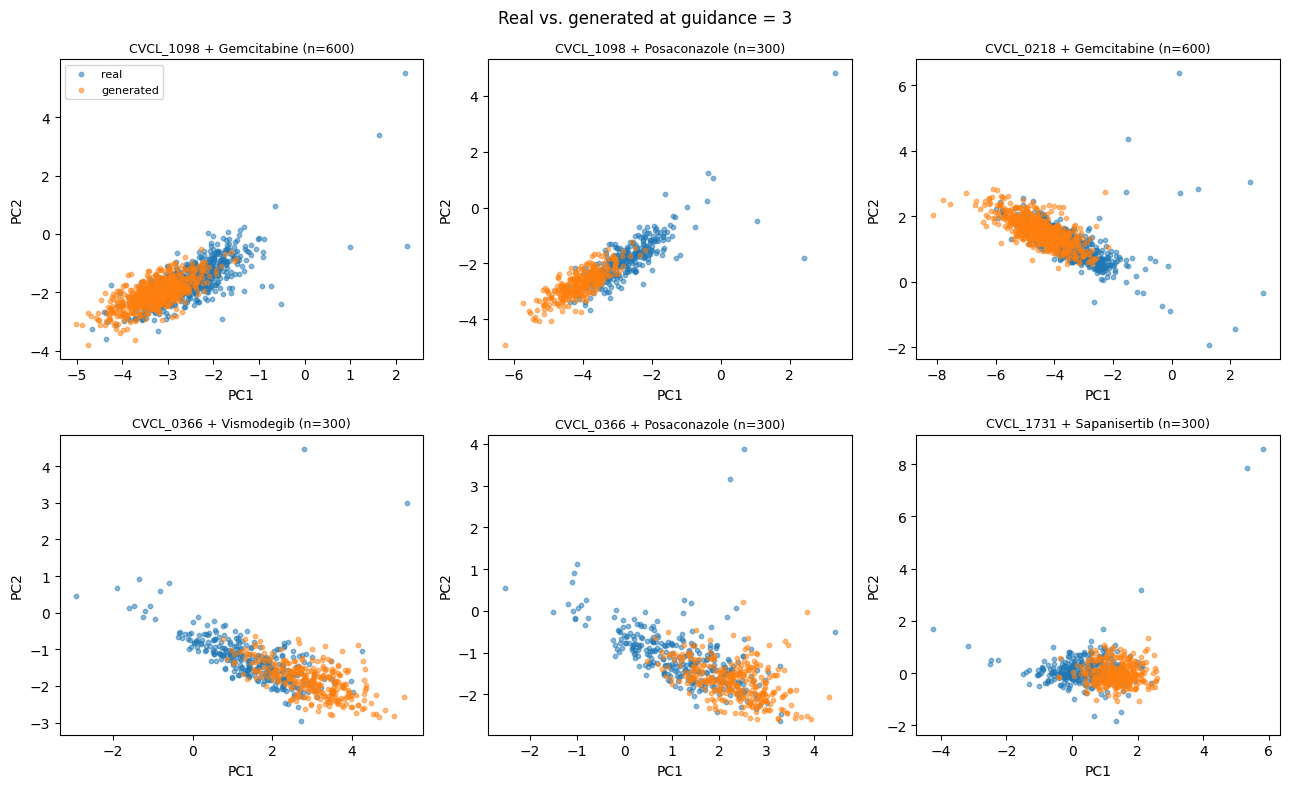

In [ ]:
import matplotlib.pyplot as plt


def eligible_pairs(dataset, min_cells=30, dmso_id=0):
    """(line_id, drug_id) treated pairs with at least min_cells real cells, for a fair overlay."""
    line_id, drug_id = torch.as_tensor(dataset.line_id), torch.as_tensor(dataset.drug_id)
    treated = drug_id != dmso_id
    pairs, counts = torch.unique(torch.stack([line_id[treated], drug_id[treated]], dim=1), dim=0, return_counts=True)
    return pairs[counts >= min_cells]


N_OVERLAY_PAIRS = 6
OVERLAY_GUIDANCE = 3.0
OVERLAY_SEED = 0

candidates = eligible_pairs(train_loader.dataset)
order = torch.randperm(len(candidates), generator=torch.Generator().manual_seed(OVERLAY_SEED))
picked = candidates[order[:N_OVERLAY_PAIRS]]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (line_id, drug_id) in zip(axes.flat, picked.tolist()):
    line_name, drug_name = line_names[line_id], drug_names[drug_id]
    mask = (train_loader.dataset.line_id == line_id) & (train_loader.dataset.drug_id == drug_id)
    real = train_loader.dataset.pcs[torch.from_numpy(mask)]
    generated = sample(model, scheduler, drug_name, line_name, len(real), OVERLAY_GUIDANCE, DATA_DIM, DEVICE,
                       seed=OVERLAY_SEED)
    ax.scatter(real[:, 0], real[:, 1], s=10, alpha=0.5, color="tab:blue", label="real")
    ax.scatter(generated[:, 0].cpu(), generated[:, 1].cpu(), s=10, alpha=0.5, color="tab:orange", label="generated")
    ax.set_title(f"{line_name} + {drug_name} (n={len(real)})", fontsize=9)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
for ax in axes.flat[len(picked):]:
    ax.axis("off")
axes.flat[0].legend(fontsize=8)
fig.suptitle(f"Real vs. generated at guidance = {OVERLAY_GUIDANCE:g}")
plt.tight_layout()
plt.show()

## 12. Visual check: guidance-scale sweep

Generates the demo pair from section 10 at several guidance scales and plots each against the same real cells (light gray). At `guidance = 0` (fully unconditional) samples should look like a generic blob unrelated to this specific pair; as guidance increases they should visibly pull toward the real cloud's actual location and shape. If they don't move at all across the sweep, the conditioning isn't being used by the model; if they collapse to a single point at high guidance, that's the usual guidance/diversity tradeoff.

In [ ]:
GUIDANCE_SWEEP = [0.0, 1.0, 3.0, 6.0]

real_mask_demo = (train_loader.dataset.line_id == line_to_id[DEMO_LINE]) & (train_loader.dataset.drug_id == drug_to_id[DEMO_DRUG])
real_demo = train_loader.dataset.pcs[torch.from_numpy(real_mask_demo)]

fig, axes = plt.subplots(1, len(GUIDANCE_SWEEP), figsize=(4 * len(GUIDANCE_SWEEP), 4), sharex=True, sharey=True)
for ax, guidance in zip(axes, GUIDANCE_SWEEP):
    generated = sample(model, scheduler, DEMO_DRUG, DEMO_LINE, len(real_demo), guidance, DATA_DIM, DEVICE, seed=0)
    ax.scatter(real_demo[:, 0], real_demo[:, 1], s=10, alpha=0.3, color="tab:gray", label="real")
    ax.scatter(generated[:, 0].cpu(), generated[:, 1].cpu(), s=10, alpha=0.6, color="tab:red", label="generated")
    ax.set_title(f"guidance = {guidance:g}")
    ax.set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=8)
fig.suptitle(f"CFG guidance sweep: {DEMO_LINE} + {DEMO_DRUG}")
plt.tight_layout()
plt.show()